# **Compute Inter Annotator Agreement (IAA) 🧮**

This notebook establishes a human performance baseline for evaluating Large Language Models (LLMs) on metadata extraction from Molecular Dynamics (MD) simulation texts. Three domain experts independently annotated 160 dataset descriptions across six categories: *molecule names* (`MOL`), *force fields or models* (`FFM`), *software names* (`SOFTNAME`) and *versions* (`SOFTVERS`), *simulation times* (`STIME`), and *temperatures* (`STEMP`). 

#### **Why IAA Matters for LLM Benchmarking**
* **Human Baseline:** Establishes the average human expert agreement reference point. It serves as a comparative benchmark to determine whether an LLM reaches or exceeds human-level consistency.
* **Guideline Refinement:** Disagreements reveal underlying ambiguities across all categories and help identify unclear or missing rules in the annotation guidelines.
* **Benchmark Quality:** Ensures a high-signal, low-bias ground truth for downstream model evaluation.

#### **Metrics Summary**
| Metric Level | Evaluation Focus | Primary Metric | Target Threshold |
| --- | --- | --- | --- |
| **Entity-Level** | Boundary & Category Exact Match | Micro-averaged Precision / Recall / $F_1$ | $F_1 \ge 0.70 $ |
| **Token-Level** | Categorical Multi-Rater Reliability | Fleiss’ Kappa ($\kappa_F$) | $\kappa \ge 0.70$ (Substantial Agreement) |


## **Load libraries and setup**

In [32]:
import ast
import json
from collections import Counter, defaultdict
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spacy
from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.inter_rater import fleiss_kappa

nlp = spacy.blank("en")

In [33]:
%load_ext watermark
%watermark

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Last updated: 2026-08-20T15:45:17.461353+02:00

Python implementation: CPython
Python version       : 3.13.0
IPython version      : 8.13.2

Compiler    : Clang 18.1.8 
OS          : Linux
Release     : 7.0.0-29-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 32
Architecture: 64bit



## **1. Loading the annotations**
We read the raw export, reduce every entity to a `(start, end, category)` triple, and score each annotation against the reference by counting true positives (TP), false positives (FP) and false negatives (FN).

In [34]:
df = pd.read_csv("../data/md_expert_groundtruth_annotation.csv")
print(f"Loaded {len(df)} annotations from {df['annotator'].nunique()} annotators")
df.head()

Loaded 479 annotations from 3 annotators


,agreement,annotation_id,annotator,created_at,entities,id,label,lead_time,raw_text,updated_at,url
0,33.33,98913508,175922,2026-07-08T14:20:40.710108Z,"[{""end"":27,""text"":""mannose"",""start"":20,""catego...",268138565,"[{""end"":27,""text"":""mannose"",""start"":20,""labels...",88.007,All atomistic MD of mannose binding interface ...,2026-07-08T14:20:40.710122Z,https://zenodo.org/records/17550324
1,33.33,97146539,175924,2026-06-08T13:14:12.634466Z,"[{""end"":27,""text"":""mannose"",""start"":20,""catego...",268138565,"[{""end"":27,""text"":""mannose"",""start"":20,""labels...",96.276,All atomistic MD of mannose binding interface ...,2026-06-08T13:14:12.634483Z,https://zenodo.org/records/17550324
2,33.33,96431692,175921,2026-05-26T09:04:56.251256Z,"[{""end"":27,""text"":""mannose"",""start"":20,""catego...",268138565,"[{""end"":27,""text"":""mannose"",""start"":20,""labels...",1423.722,All atomistic MD of mannose binding interface ...,2026-05-28T09:47:36.066806Z,https://zenodo.org/records/17550324
3,33.33,99082153,175922,2026-07-10T14:08:07.765893Z,"[{""end"":81,""text"":""n-alkanes"",""start"":72,""cate...",268138566,"[{""end"":117,""text"":""CHARMM36"",""start"":109,""lab...",8317.805,"MD simulation input files and results for ,,At...",2026-07-10T14:08:07.765905Z,https://zenodo.org/records/7572990
4,33.33,97136566,175924,2026-06-08T10:37:25.416481Z,"[{""end"":81,""text"":""n-alkanes"",""start"":72,""cate...",268138566,"[{""end"":81,""text"":""n-alkanes"",""start"":72,""labe...",149.322,"MD simulation input files and results for ,,At...",2026-06-08T10:37:25.416492Z,https://zenodo.org/records/7572990


In [35]:
# Type alias for entity tuples: (start, end, category)
Entity = tuple[int, int, str]


def parse_entities(raw: list, category_key: str) -> list[Entity]:
    """Parse a raw string of entities into a list of (start, end, category) tuples.

    Returns
    -------
    A list of (start, end, category) entity tuples parsed from a raw string.
    """
    if pd.isna(raw):
        return []
    try:
        items = json.loads(raw)
    except (TypeError, json.JSONDecodeError):
        items = ast.literal_eval(raw)

    # Extract entities and handle category list/string variations
    entities = []
    for item in items:
        cat = item.get(category_key, "UNKNOWN")
        cat = cat[0] if isinstance(cat, list) and cat else cat
        entities.append((item["start"], item["end"], str(cat)))
    return entities


def match_entities(
    gt_entities: list[Entity], pred_entities: list[Entity]
) -> tuple[int, int, int]:
    """Compute exact-match true TP, FP, FN between ground truth and predicted entities.

    Returns
    -------
    A tuple of (TP, FP, FN) exact-match entity counts.
    """
    gt_set, pred_set = set(gt_entities), set(pred_entities)
    return len(gt_set & pred_set), len(pred_set - gt_set), len(gt_set - pred_set)


# Parse ground truth and predicted entities
df["gt_entities"] = df["entities"].apply(lambda x: parse_entities(x, "category"))
df["pred_entities"] = df["label"].apply(lambda x: parse_entities(x, "labels"))
# Compute exact-match TP, FP, FN per row
df[["tp", "fp", "fn"]] = df.apply(
    lambda r: match_entities(r["gt_entities"], r["pred_entities"]),
    axis=1,
    result_type="expand",
)
df = df[
    [
        "id",
        "annotator",
        "raw_text",
        "gt_entities",
        "pred_entities",
        "tp",
        "fp",
        "fn",
        "lead_time",
    ]
]
df.head()

,id,annotator,raw_text,gt_entities,pred_entities,tp,fp,fn,lead_time
0,268138565,175922,All atomistic MD of mannose binding interface ...,"[(20, 27, MOL), (49, 56, MOL), (61, 65, MOL), ...","[(20, 27, MOL), (49, 56, MOL), (61, 65, MOL), ...",13,3,3,88.007
1,268138565,175924,All atomistic MD of mannose binding interface ...,"[(20, 27, MOL), (49, 56, MOL), (61, 65, MOL), ...","[(20, 27, MOL), (49, 56, MOL), (61, 65, MOL), ...",16,0,0,96.276
2,268138565,175921,All atomistic MD of mannose binding interface ...,"[(20, 27, MOL), (49, 56, MOL), (61, 65, MOL), ...","[(20, 27, MOL), (282, 289, MOL), (654, 661, ST...",13,3,3,1423.722
3,268138566,175922,"MD simulation input files and results for ,,At...","[(72, 81, MOL), (87, 99, MOL), (109, 117, FFM)...","[(109, 117, FFM), (277, 285, FFM), (624, 629, ...",4,6,10,8317.805
4,268138566,175924,"MD simulation input files and results for ,,At...","[(72, 81, MOL), (87, 99, MOL), (109, 117, FFM)...","[(72, 81, MOL), (87, 99, MOL), (109, 117, FFM)...",14,0,0,149.322


## **2. Annotator profiles: accuracy and speed**
For each expert we aggregate their TP/FP/FN counts into precision, recall and F1 against the reference, and look at how long they took per text.

$$
P = \frac{TP}{TP+FP} \qquad R = \frac{TP}{TP+FN} \qquad F_1 = \frac{2PR}{P+R} = \frac{2\,TP}{2\,TP+FP+FN}
$$

In [36]:
summary = df.groupby("annotator").agg(
    tp=("tp", "sum"),
    fp=("fp", "sum"),
    fn=("fn", "sum"),
    n_annotations=("id", "count"),
    mean_time_sec=("lead_time", "mean"),
    median_time_sec=("lead_time", "median"),
)

summary["precision"] = summary["tp"] / (summary["tp"] + summary["fp"])
summary["recall"] = summary["tp"] / (summary["tp"] + summary["fn"])
summary["f1"] = (
    2
    * summary["precision"]
    * summary["recall"]
    / (summary["precision"] + summary["recall"])
)

summary = summary.fillna(0).sort_values("f1", ascending=False)
display(summary.reset_index())

,annotator,tp,fp,fn,n_annotations,mean_time_sec,median_time_sec,precision,recall,f1
0,175924,2404,57,101,160,1710.594200,114.3240,0.976839,0.959681,0.968184
1,175921,1710,642,795,160,1034.480288,228.7765,0.727041,0.682635,0.704138
2,175922,1628,568,864,159,4374.404208,107.0770,0.741348,0.653291,0.694539


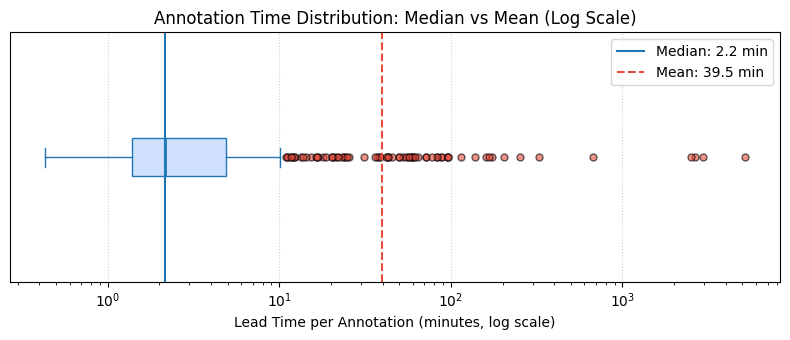

In [ ]:
lead_time_min = df["lead_time"] / 60
mean_val = lead_time_min.mean()
median_val = lead_time_min.median()

fig, ax = plt.subplots(figsize=(8, 3.5))
# Log-scale boxplot
lead_time_min.plot.box(
    vert=False,
    ax=ax,
    patch_artist=True,
    boxprops={"facecolor": "#d0e1fd", "color": "#1f77b4"},
    medianprops={"color": "#1f77b4", "linewidth": 2},
    flierprops={
        "marker": "o",
        "markerfacecolor": "#e74c3c",
        "alpha": 0.6,
        "markersize": 5,
    },
)
# Reference lines
ax.axvline(
    median_val,
    color="#1f77b4",
    linestyle="-",
    linewidth=1.5,
    label=f"Median: {median_val:.1f} min",
)
ax.axvline(
    mean_val,
    color="#e74c3c",
    linestyle="--",
    linewidth=1.5,
    label=f"Mean: {mean_val:.1f} min",
)
ax.set_xscale("log")
ax.set_xlabel("Lead Time per Annotation (minutes, log scale)")
ax.set_title("Annotation Time Distribution: Median vs Mean (Log Scale)")
ax.set_yticks([])
ax.grid(axis="x", linestyle=":", alpha=0.6)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

The gap between the median (~2 min) and the mean (~40 min) is caused by inactive sessions. The median is therefore more representative of the real annotation speed.

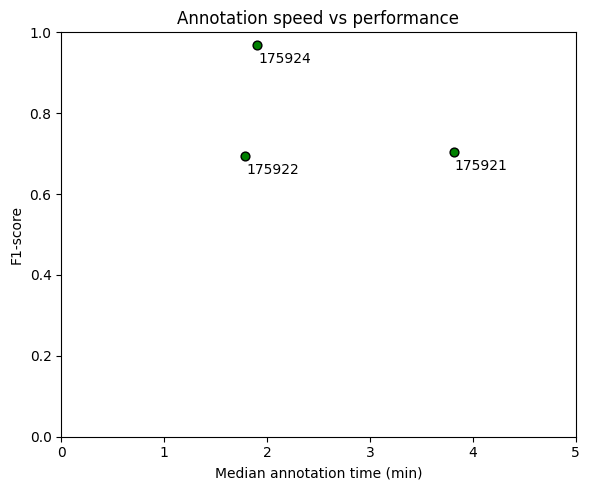

In [38]:
summary["median_time_min"] = summary.median_time_sec / 60
ax = summary.plot.scatter(
    x="median_time_min",
    y="f1",
    s=40,
    color="green",
    edgecolor="black",
    figsize=(6, 5),
)
for n, r in summary.iterrows():
    ax.annotate(
        n, (r.median_time_min, r.f1), xytext=(1, -13), textcoords="offset points"
    )

ax.set(
    xlabel="Median annotation time (min)",
    ylabel="F1-score",
    ylim=(0, 1),
    xlim=(0, 5),
    title="Annotation speed vs performance",
)
plt.tight_layout()

## **3. How much do the experts agree?**

Before evaluating an AI system, we first need to assess how consistently the experts annotate the data. If experts disagree on a category, the reference annotation contains some uncertainty, which limits the maximum performance that an automatic system can realistically achieve. Inter-annotator agreement was measured using **Cohen's kappa** ([Cohen, 1960](https://psycnet.apa.org/doi/10.1177/001316446002000104)), a metric that quantifies the agreement between two annotators while correcting for agreement that could occur by chance. Each text was tokenized, and every token was assigned an IOB2 label, allowing annotator agreement to be compared at the token level. It is defined as:

$$
\kappa = \frac{p_o - p_e}{1 - p_e}
$$

where $p_o$ is the observed agreement between annotators and $p_e$ is the expected agreement by chance. A value close to 1 indicates strong agreement, while values close to 0 indicate agreement equivalent to chance.

In [39]:
def tokenize_and_label(text: str, entities: list[tuple[int, int, str]]) -> list[str]:
    """Tokenize text with spaCy and assign IOB2 labels from entity spans.

    Returns
    -------
    A list of IOB2 labels corresponding to the tokens in the input text.
    """
    doc = nlp(text)
    labels = ["O"] * len(doc)
    for start, end, category in entities:
        idxs = [i for i, t in enumerate(doc) if t.idx < end and t.idx + len(t) > start]
        for n, i in enumerate(idxs):
            labels[i] = f"{'B' if n == 0 else 'I'}-{category}"
    return labels


def binary(labels: list[str], cat: str) -> list[int]:
    """Convert a list of IOB2 labels to a binary vector for a specific category.

    Returns
    -------
    A list of 0s and 1s indicating the presence of the specified category in the labels.
    """
    return [int(cat in label) for label in labels]


categories = sorted({cat for ents in df["pred_entities"] for *_, cat in ents})
multi_annotations = df.groupby("id").filter(lambda g: len(g) > 1)

pairs = defaultdict(lambda: ([], []))
for _, group in multi_annotations.groupby("id"):
    labels = {
        row.annotator: tokenize_and_label(row.raw_text, row.pred_entities)
        for _, row in group.iterrows()
    }
    for a, b in combinations(sorted(labels), 2):
        l1, l2 = pairs[f"{a} vs {b}"]
        l1.extend(labels[a])
        l2.extend(labels[b])

agreement_df = pd.DataFrame(
    {
        pair: {
            **{c: cohen_kappa_score(binary(l1, c), binary(l2, c)) for c in categories},
            "OVERALL": cohen_kappa_score(l1, l2),
        }
        for pair, (l1, l2) in pairs.items()
    }
).T
display(agreement_df.round(2))


,FFM,MOL,SOFTNAME,SOFTVERS,STEMP,STIME,OVERALL
175921 vs 175922,0.79,0.72,0.63,0.61,0.81,0.62,0.72
175921 vs 175924,0.81,0.80,0.74,0.62,0.89,0.88,0.80
175922 vs 175924,0.88,0.73,0.74,0.87,0.88,0.64,0.76


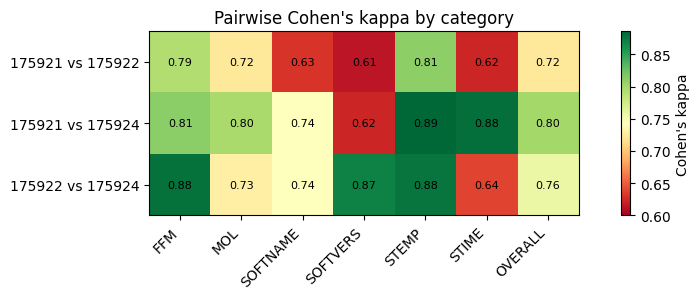

In [40]:
values = agreement_df.to_numpy()
fig, ax = plt.subplots(
    figsize=(1.1 * len(agreement_df.columns) + 2, 1 + 0.7 * len(agreement_df))
)
im = ax.imshow(values, cmap="RdYlGn", vmin=0.6)

ax.set_xticks(
    range(len(agreement_df.columns)), agreement_df.columns, rotation=45, ha="right"
)
ax.set_yticks(range(len(agreement_df)), agreement_df.index)
for (i, j), v in np.ndenumerate(values):
    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Pairwise Cohen's kappa by category")
fig.colorbar(im, label="Cohen's kappa")
plt.tight_layout()
plt.show()


## 4. **What do disagreements actually look like?**

A kappa value tells us *how much* annotators disagree on a category, but not *why*. For each category, we pull one concrete text where the experts' spans differ, to see whether the disagreement is a missed entity, an extra one, or a different reading of the same phrase.

In [41]:
def entities_of_category(entities: list, category: str) -> list[tuple[int, int]]:
    """Return (start, end) spans for entities of a specific category.

    Returns
    -------
    A list of (start, end) tuples for entities matching the given category.
    """
    return [(start, end) for start, end, cat in entities if cat == category]


def align_disagreements(
    text: str, spans_first: list, spans_second: list
) -> list[tuple[str, str]]:
    """Pair overlapping entity spans between two annotators, keeping only mismatches.

    Returns
    -------
    A list of (surface_first, surface_second) pairs, using "—" when one
    annotator has no matching span.
    """
    remaining_second = list(spans_second)
    mismatches = []
    for span_first in spans_first:
        match = next(
            (
                span_second
                for span_second in remaining_second
                if span_second[0] < span_first[1] and span_first[0] < span_second[1]
            ),
            None,
        )
        if match is not None:
            remaining_second.remove(match)
            surface_first = text[span_first[0] : span_first[1]].strip()
            surface_second = text[match[0] : match[1]].strip()
            if surface_first != surface_second:
                mismatches.append((surface_first, surface_second))
        else:
            mismatches.append((text[span_first[0] : span_first[1]].strip(), "—"))
    mismatches += [
        ("—", text[span_second[0] : span_second[1]].strip())
        for span_second in remaining_second
    ]
    return mismatches


def disagreements_for_text(text_id: str, group: pd.DataFrame) -> list[dict]:
    """Compute all pairwise entity disagreements for a single annotated text.

    Returns
    -------
    A list of disagreement rows (dicts), one per category and annotator pair.
    """
    text = group["raw_text"].iloc[0]
    rows = []
    for category in categories:
        spans = {
            row["annotator"]: entities_of_category(row["pred_entities"], category)
            for _, row in group.iterrows()
        }
        for annotator_a, annotator_b in combinations(sorted(spans), 2):
            rows += [
                {
                    "id": text_id,
                    "category": category,
                    "annotator_a": annotator_a,
                    "annotator_b": annotator_b,
                    "annotation_a": entity_a,
                    "annotation_b": entity_b,
                    "text": text,
                }
                for entity_a, entity_b in align_disagreements(
                    text, spans[annotator_a], spans[annotator_b]
                )
            ]
    return rows


disagreement_rows = [
    row
    for text_id, group in multi_annotations.groupby("id")
    for row in disagreements_for_text(text_id, group)
]
disagreements_df = pd.DataFrame(disagreement_rows)
disagreements_df = disagreements_df[
    disagreements_df["annotation_a"] != disagreements_df["annotation_b"]
]
print(f"Found {len(disagreements_df)} disagreements: ")
disagreements_df

Found 3485 disagreements: 


,id,category,annotator_a,annotator_b,annotation_a,annotation_b,text
0,268138565,MOL,175921,175922,2023.2,—,All atomistic MD of mannose binding interface ...
1,268138565,MOL,175921,175922,CRD,—,All atomistic MD of mannose binding interface ...
2,268138565,MOL,175921,175922,—,sugar receptor protein,All atomistic MD of mannose binding interface ...
3,268138565,MOL,175921,175922,—,water,All atomistic MD of mannose binding interface ...
4,268138565,MOL,175921,175924,2023.2,—,All atomistic MD of mannose binding interface ...
...,...,...,...,...,...,...,...
3480,274606954,MOL,175922,175924,—,IP15,"Simulation input files, trajectory files and P..."
3481,274606954,STIME,175921,175922,—,1500ns,"Simulation input files, trajectory files and P..."
3482,274606954,STIME,175921,175922,—,1000 ps,"Simulation input files, trajectory files and P..."
3483,274606954,STIME,175921,175924,—,1500ns,"Simulation input files, trajectory files and P..."


> Note: We can't see spaces but it counts as a character difference, which would otherwise flag identical-looking annotations as a mismatch.

## 5. **Global consensus and overall effort**
Finally, we step back from pairs and look at the group as a whole with Fleiss' kappa, which generalises Cohen's kappa to more than two raters:

$$
\kappa = \frac{\bar{P} - \bar{P_e}}{1 - \bar{P_e}}
$$

where $\bar{P}$ is the mean observed agreement across all annotated tokens and $\bar{P_e}$ is the agreement expected by chance given the overall label distribution.

In [42]:
df_fleiss = df.groupby("id").filter(lambda group: len(group) == 3)
all_labels, token_votes = set(), []

for _, group in df_fleiss.groupby("id"):
    labels = [
        tokenize_and_label(group["raw_text"].iloc[0], row.pred_entities)
        for _, row in group.iterrows()
    ]
    all_labels.update(label for annotator in labels for label in annotator)
    token_votes.extend(zip(*labels, strict=False))

sorted_labels = sorted(all_labels)
matrix = np.array(
    [[Counter(votes).get(label, 0) for label in sorted_labels] for votes in token_votes]
)
fleiss = fleiss_kappa(matrix)

print("--- Global consensus (Fleiss' kappa) ---")
print(f"Tokens evaluated:     {len(matrix)}")
print(f"IOB label categories: {len(sorted_labels)}")
print(f"Fleiss' kappa:        {fleiss:.4f}\n")


--- Global consensus (Fleiss' kappa) ---
Tokens evaluated:     37704
IOB label categories: 13
Fleiss' kappa:        0.7601



In [43]:
print("--- Overall annotation effort ---")
stats = df["lead_time"].agg(["mean", "median", "min", "max"])
print(
    f"Total texts: {df['id'].nunique()}\n"
    f"Number of annotators: {df['annotator'].nunique()}\n"
    f"Mean time: {stats['mean']:.2f}s ({stats['mean'] / 60:.2f} min)\n"
    f"Median time: {stats['median']:.2f}s  ({stats['median'] / 60:.2f} min)\n"
    f"Min / Max: {stats['min']:.2f}s / {stats['max'] / 3600:.2f} h"
)

--- Overall annotation effort ---
Total texts: 160
Number of annotators: 3
Mean time: 2368.98s (39.48 min)
Median time: 129.60s  (2.16 min)
Min / Max: 25.91s / 86.22 h
